# Step 5: Exploratory Data Analysis and Visualization with Matplotlib and Seaborn

**Data Science Journey 2026 — @datasciencehorizon**

Before you build any Machine Learning model, you must understand your data. Exploratory Data Analysis (EDA) is the process of analysing and visualising data to get insights *before* modelling begins.

> "A picture is worth a thousand words." The goal of data visualisation is to explore your data in as many ways as possible until you understand it completely.

In every dataset you have **features** (variables) and a **target** (label). EDA helps you understand each feature on its own, and the relationships between features. Without EDA, you're building a model on data you don't understand — that's like driving with your eyes closed.

We'll use two libraries:
- **Matplotlib** — the foundation, the most widely used plotting library in Python
- **Seaborn** — built on top of Matplotlib, makes beautiful statistical visualisations with much less code

Full write-up: [datasciencehorizon.com](https://datasciencehorizon.com)


## 1. Imports and Loading the Dataset

We'll use the classic **Iris dataset** — 150 flowers, 3 species, 4 features.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")

iris = load_iris()
iris_df = pd.DataFrame(data=iris['data'], columns=iris['feature_names'])
iris_df['Species'] = pd.Series(iris['target']).apply(
    lambda x: 'setosa' if x == 0 else ('versicolor' if x == 1 else 'virginica'))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The Iris dataset: **150 flowers, 3 species** — Setosa, Versicolor, Virginica.
**Four features**: Sepal Length, Sepal Width, Petal Length, Petal Width.
**50 samples per species** — perfectly balanced. Let's confirm that.

In [2]:
print("Shape:", iris_df.shape)
iris_df['Species'].value_counts()

Shape: (150, 5)


Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 2. Univariate Analysis

EDA has two main types:
- **Univariate Analysis** — analyse one variable at a time
- **Bivariate Analysis** — analyse the relationship between two variables

For **continuous** variables (like Petal Length) → histograms, box plots, PDF curves.
For **categorical** variables (like Species) → bar plots and pie charts.

### Bar Plot — Frequency of Each Species

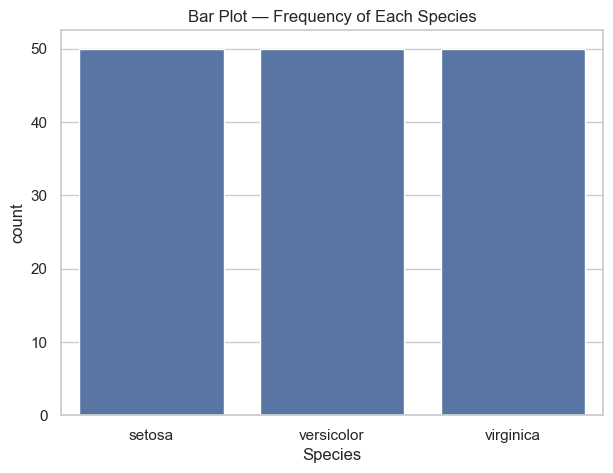

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Species', data=iris_df)
plt.title('Bar Plot — Frequency of Each Species')
plt.show()

All three bars are the same height — **50 each**. This confirms our dataset is balanced. In real-world data, this is almost never the case — imbalanced datasets require special ML techniques. Always check this first.

### Pie Chart — Proportion of Each Species

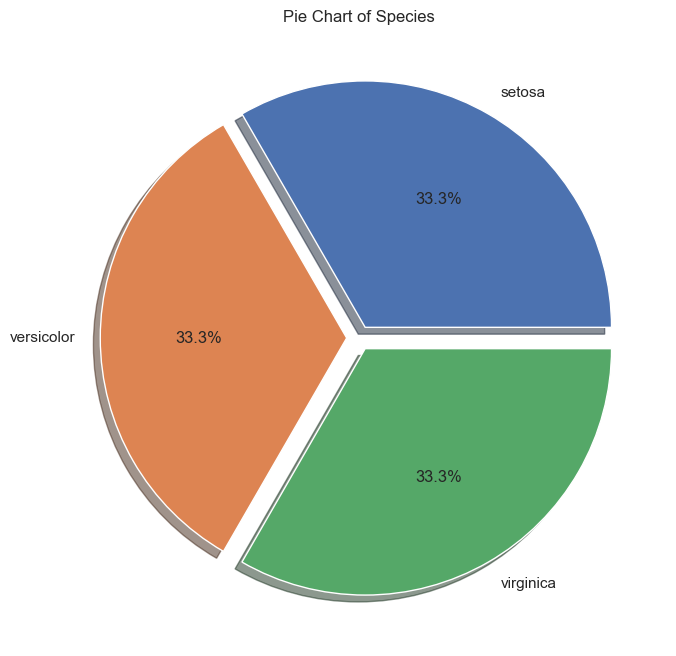

In [11]:
iris_df['Species'].value_counts().plot.pie(
    explode=[0.05, 0.05, 0.05], autopct='%1.1f%%',
    shadow=True, figsize=(8, 8))
plt.title('Pie Chart of Species')
plt.ylabel('')
plt.show()

Again — **33.3% each**. Balanced dataset confirmed a second time.

### Box Plot — Five-Number Summary

A box plot gives you a five-number summary of any variable in one picture: **minimum, Q1, median, Q3, maximum**. Anything beyond the whiskers is an outlier.

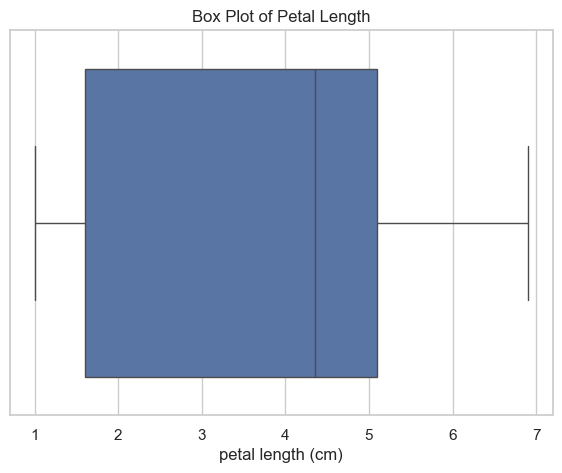

Min: 1.0
Q1: 1.6
Median: 4.35
Q3: 5.1
Max: 6.9


In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=iris_df['petal length (cm)'])
plt.title('Box Plot of Petal Length')
plt.show()

print("Min:", iris_df['petal length (cm)'].min())
print("Q1:", iris_df['petal length (cm)'].quantile(0.25))
print("Median:", iris_df['petal length (cm)'].median())
print("Q3:", iris_df['petal length (cm)'].quantile(0.75))
print("Max:", iris_df['petal length (cm)'].max())

From this one chart: minimum petal length ≈ 1.0 cm, maximum ≈ 6.9 cm, median ≈ 4.3 cm, Q1 ≈ 1.6, Q3 ≈ 5.1, IQR ≈ 3.5 — and no outliers. **Five statistical insights from a single chart.**

### Histogram + PDF

A histogram shows the distribution of a numerical variable across ranges called **bins**. The **PDF** (Probability Density Function) is the smooth curve on top — the continuous version of the histogram.

Let's plot Petal Length separately for each species.

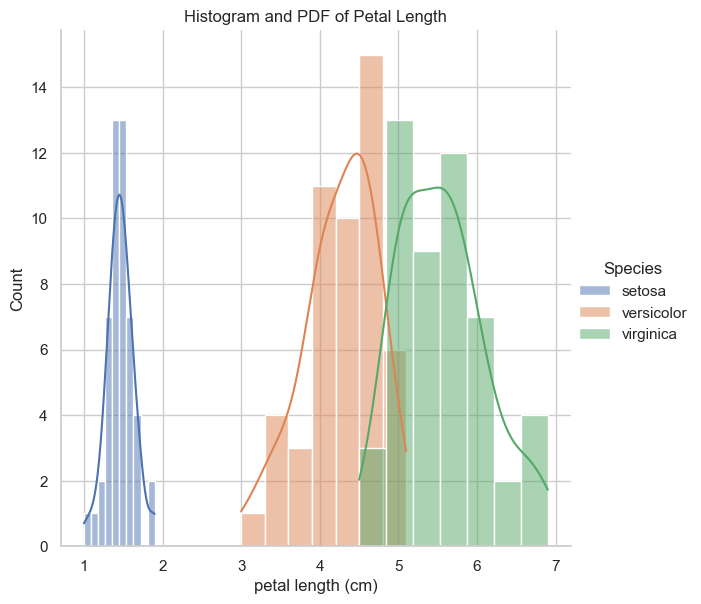

In [13]:
g = sns.FacetGrid(iris_df, hue="Species", height=6)
g.map(sns.histplot, "petal length (cm)", kde=True)
g.add_legend()
plt.title('Histogram and PDF of Petal Length')
plt.show()

**Setosa** (blue) is completely separated on the left — entirely between 1–2 cm. **Versicolor** and **Virginica** overlap — harder to separate. This tells us Petal Length will be a very useful feature for our ML model, *before we've even built one*.

## 3. Bivariate Analysis

Now we look at the relationship between **two** variables:
- Two continuous variables → **Scatter Plots** and **Correlation**
- One continuous + one categorical → **Box Plots split by category**
- Two categorical variables → **Cross-tabulation** and grouped bar charts

### Scatter Plot — Sepal Length vs Sepal Width

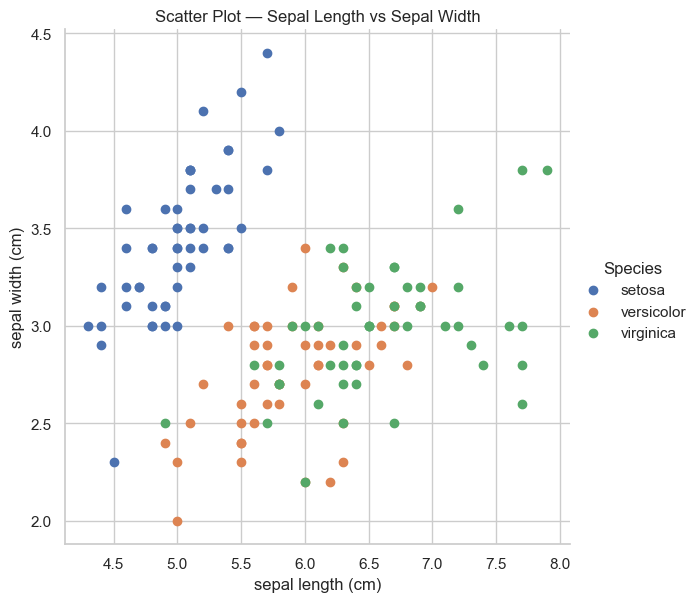

In [14]:
g = sns.FacetGrid(iris_df, hue="Species", height=6)
g.map(plt.scatter, "sepal length (cm)", "sepal width (cm)")
g.add_legend()
plt.title("Scatter Plot — Sepal Length vs Sepal Width")
plt.show()

**Setosa** (blue dots) is clearly separated. But **Versicolor** and **Virginica** overlap heavily in Sepal Length/Width — these two features alone aren't enough to cleanly separate all three species.

### Box Plot by Species — Petal Length

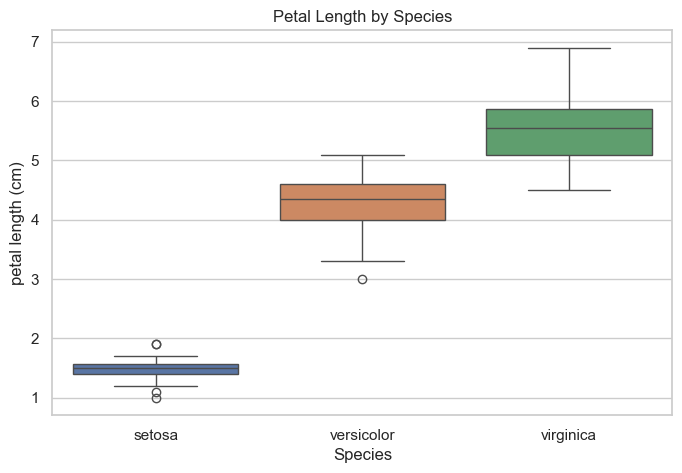

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Species', y='petal length (cm)', data=iris_df, hue='Species', legend=False)
plt.title('Petal Length by Species')
plt.show()

Now clearly: **Setosa** has the smallest petal length, **Virginica** the largest, with some outliers in Versicolor and Setosa. Each species has a distinct petal length range — excellent for classification.

## 4. Pair Plot — The Most Powerful Single Visualisation

A pair plot shows the distribution of **every** variable and the relationship between **every pair** of variables — all in one chart, one line of code.

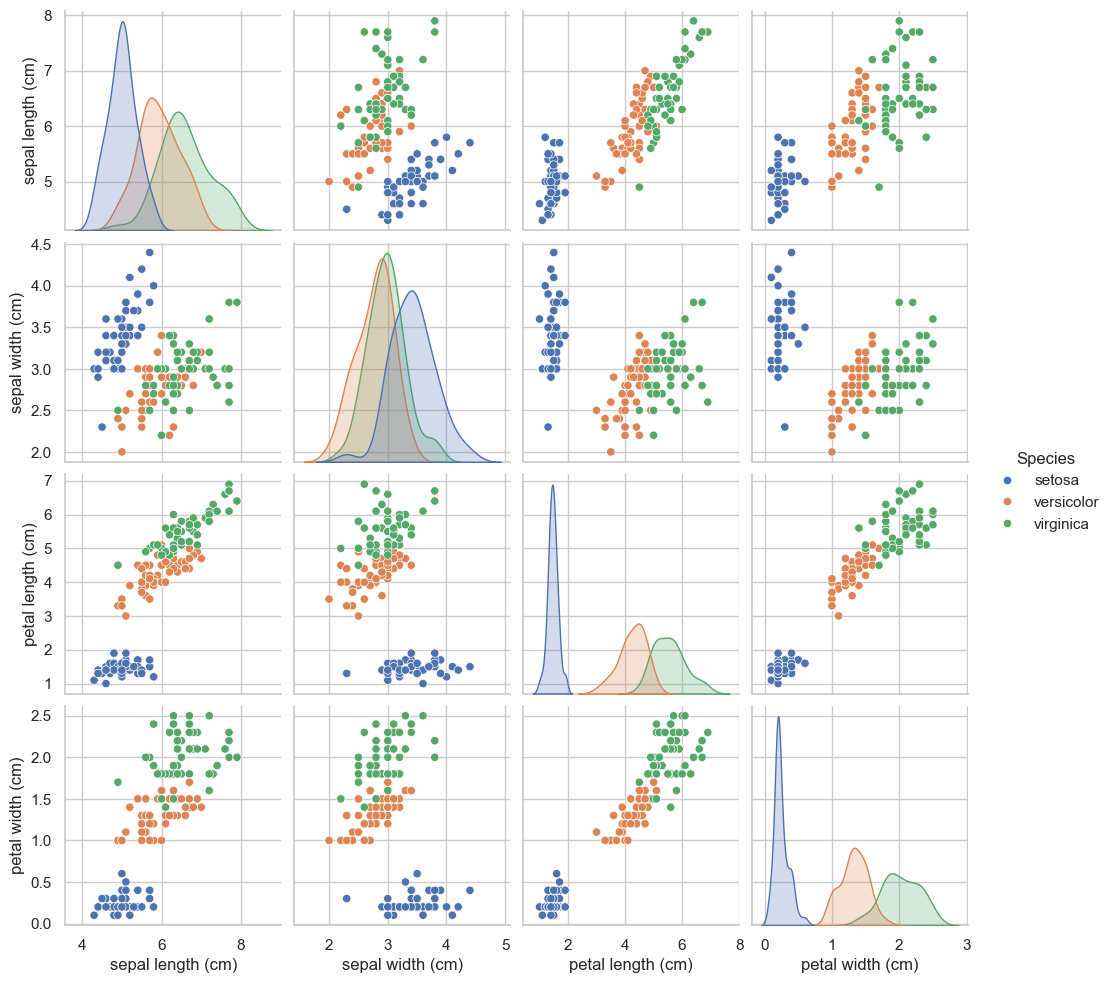

In [19]:
sns.pairplot(iris_df, hue="Species")
plt.show()

The **diagonal** plots show the PDF of each individual feature — that's Univariate Analysis. Every **other cell** shows the scatter plot between two features — that's Bivariate Analysis. All in one command.

**Key insight**: Petal Length and Petal Width are the most useful, separable features. Setosa is completely separate in both. Versicolor and Virginica overlap somewhat but are mostly distinguishable. This one chart tells us which features the ML model should prioritise — before writing a single line of ML code.

## 5. Heatmap — Correlation Between Features

A heatmap uses colour to show the correlation between every pair of numerical features. Values range from **-1 to +1**: 1 = perfect positive correlation, 0 = no correlation, -1 = perfect negative correlation.

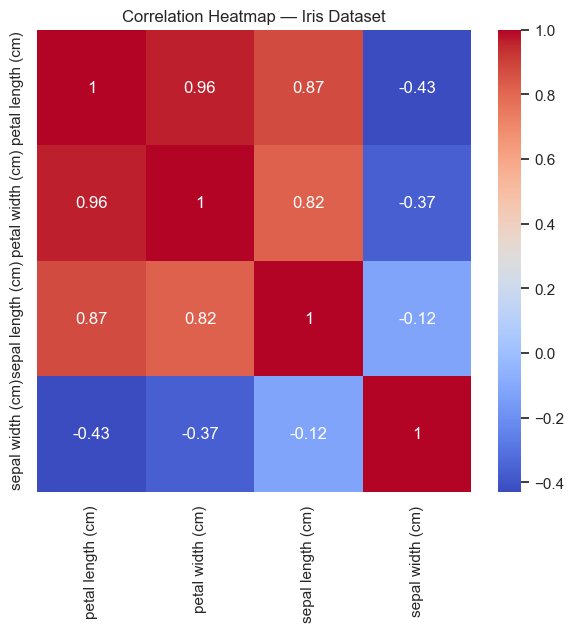

In [20]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    iris_df[['petal length (cm)', 'petal width (cm)',
             'sepal length (cm)', 'sepal width (cm)']].corr(),
    annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap — Iris Dataset')
plt.show()

Three key insights:
1. **Petal Length & Petal Width** → correlation ≈ 0.96 — almost perfectly correlated, they move together.
2. **Petal Length & Sepal Length** → strong positive correlation ≈ 0.87.
3. **Sepal Width** → negative correlation with all three other features.

This tells us which features carry similar information — critical for feature selection before Machine Learning.

## Summary

We used the **Iris dataset** — 150 flowers, 3 species, 4 features.

**Univariate Analysis**: bar plot and pie chart (categorical Species) → histogram, PDF, and box plot (continuous Petal Length).

**Bivariate Analysis**: scatter plots and species box plots to understand relationships between features.

**Pair Plot**: all variables together, one command.

**Heatmap**: correlation between every pair of numerical features.

### Key Insights
- Petal Length and Petal Width are the most useful features for classification
- Setosa is easily separable from the other two species
- Versicolor and Virginica overlap in sepal measurements, but are separable in petal measurements
- Sepal Width has a negative correlation with the other three features

All of this — **before a single Machine Learning model was built.**

---
More at [datasciencehorizon.com](https://datasciencehorizon.com) · Follow **@datasciencehorizon** · Next up: **Step 6 — Build Your First Machine Learning Model**
